# 5 Transistor OTA 
## Notebook Author: Rosnel Leyva-Cortes
This notebook is an example for how to design a 5-transistor operational transconductance amplifier from python description, to netlist, to layout using the SKY130 process technology.

# Checking Imports 

In [1]:
import os 
import PySpice.Spice.Simulation
import subprocess
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from pathlib import Path

PySpice.Spice.Simulation.CircuitSimulator.DEFAULT_SIMULATOR = 'ngspice-shared'

# Haven't figured out how to port these paths onto system calls, but good to keep track of
ALIGN_PDK_DIR = './ALIGN-public/pdks/SKY130_PDK/'
ALIGN_NET_DIR = './ALIGN_WORK_DIR/'
GDS_OUTPUT_DIR = 'ALIGN_WORK_DIR/GDS_OUT'

# Function and Class Definition

In [2]:
#pyspice to align port 
def export_circuit_to_align(circuit, align_dir='ALIGN_WORK_DIR', cell_name='my_circuit'):
    """
    Exports a PySpice circuit to a SPICE netlist compatible with ALIGN.

    Parameters:
    - circuit: PySpice Circuit object
    - align_dir: str, path to ALIGN working directory
    - cell_name: str, name of the circuit (also used as subckt name and folder name)
    """
    #from PySpice.Spice.Netlist import Circuit

    if not isinstance(circuit, Circuit):
        raise ValueError("Expected a PySpice Circuit object.")

    # Create target directory
    cell_dir = Path(align_dir) / cell_name
    cell_dir.mkdir(parents=True, exist_ok=True)

    # Format the netlist string
    netlist_lines = str(circuit).splitlines()

    # Remove .include or .lib lines (ALIGN doesn't need models here)
    netlist_lines = [line for line in netlist_lines if not line.strip().lower().startswith(('.include', '.lib', '.param', '.control'))]

    # Ensure netlist is wrapped in a .subckt block if not already
    has_subckt = any(line.lower().startswith('.subckt') for line in netlist_lines)
    if not has_subckt:
        # Collect all nodes involved (rough heuristic)
        nodes = set()
        for line in netlist_lines:
            tokens = line.split()
            if tokens and tokens[0][0].upper() in 'MRCLX':
                nodes.update(tokens[1:-1])
        ports = ' '.join(sorted(nodes - {'vdd', 'vss', 'gnd'}))
        netlist_lines.insert(0, f'.subckt {cell_name} {ports}')
        netlist_lines.append(f'.ends {cell_name}')

    # Write to file
    netlist_path = cell_dir / f'{cell_name}.sp'
    with open(netlist_path, 'w') as f:
        f.write('\n'.join(netlist_lines))

    print(f" 😆 Netlist exported for ALIGN: {netlist_path}")

def create_5t_ota(vdd=1.8, w_n=10.5e-7, l_n=150e-9, w_p=10.5e-7, l_p=150e-9):
    circuit = Circuit('5T_OTA')

    # Include the Sky130 model file
    circuit.include('pySpiceLibrary/skywater-pdk/libraries/sky130_fd_pr/latest/models/corners/tt.spice')

    # NMOS differential pair
    circuit.M(1, 'Vnet1', 'VIN1', 'Vtail', 'VSS', model='sky130_fd_pr__nfet_01v8', w=w_n, l=l_n)
    circuit.M(2, 'VOUT', 'VIN2', 'Vtail', 'VSS', model='sky130_fd_pr__nfet_01v8', w=w_n, l=l_n)

    # NMOS tail current source
    circuit.M(3, 'Vtail', 'bias', 'VSS', 'VSS', model='sky130_fd_pr__nfet_01v8', w=w_n, l=l_n)

    # PMOS active load (current mirror)
    circuit.M(4, 'VOUT', 'Vnet1', 'VDD', 'VDD', model='sky130_fd_pr__pfet_01v8', w=w_p, l=l_p)
    circuit.M(5, 'Vnet1', 'Vnet1', 'VDD', 'VDD', model='sky130_fd_pr__pfet_01v8', w=w_p, l=l_p)

    return circuit

# Circuit Definition 

In [3]:
ota = create_5t_ota()
print(ota)

.title 5T_OTA
.include /PIACC/pySpiceLibrary/skywater-pdk/libraries/sky130_fd_pr/latest/models/corners/tt.spice
M1 Vnet1 VIN1 Vtail VSS sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
M2 VOUT VIN2 Vtail VSS sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
M3 Vtail bias VSS VSS sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
M4 VOUT Vnet1 VDD VDD sky130_fd_pr__pfet_01v8 l=1.5e-07 w=1.05e-06
M5 Vnet1 Vnet1 VDD VDD sky130_fd_pr__pfet_01v8 l=1.5e-07 w=1.05e-06



## Schematic
For added context for those unfamiliar with SPICE netlist connections, this is a schematic of the circuit.

# Simulation Integration #-TODO
For this portion, I recommend making a copy of your original netlist and running simulations that way. This is because in order to run simulations within this environment additional elements like adjustable sources must be embedded into the 'circuit' object which are not totally interpretable with the ALIGN framework. This notebook illustrates this method, but use whatever you feel most comfortable doing. 

# Layout Generation 

In [4]:
export_circuit_to_align(ota, align_dir=ALIGN_NET_DIR, cell_name='5t_OTA_example')

 😆 Netlist exported for ALIGN: ALIGN_WORK_DIR/5t_OTA_example/5t_OTA_example.sp


In [6]:
!schematic2layout.py './ALIGN_WORK_DIR/5t_OTA_example' -p '/ALIGN-public/pdks/SKY130_PDK/' -w './ALIGN_WORK_DIR/GDS_OUT'

align.main INFO : Reading netlist: /PIACC/ALIGN_WORK_DIR/5t_OTA_example/5t_OTA_example.sp subckt=5T_OTA_EXAMPLE, flat=0
align.compiler.compiler INFO : Starting topology identification...
align.compiler.compiler INFO : Power and ground nets not found. Power grid will not be constructed.
align.compiler.compiler INFO : Completed topology identification.
align.cell_fabric.drc ERROR : Found errors: DRC 7
align.cell_fabric.drc ERROR : Found errors: DRC 2
align.pnr.main INFO : Running Place & Route for 5T_OTA_EXAMPLE
align.pnr.build_pnr_model INFO : Reading contraint json file 5T_OTA_EXAMPLE.pnr.const.json
align.pnr.build_pnr_model INFO : Reading contraint json file 5T_OTA_EXAMPLE.pnr.const.json
align.pnr.placer INFO : Starting bottom-up placement on 5T_OTA_EXAMPLE 0
PnR.placer.SeqPair.SeqPair INFO : Enumerated search
PnR.placer.Placer.PlacementCoreAspectRatio_ILP INFO : Exhausted all permutations of seq pairs and found 1 placement solution(s)
PnR.placer.ILP_solver.updateTerminalCenter ERROR 

# Output GDS should look like this 

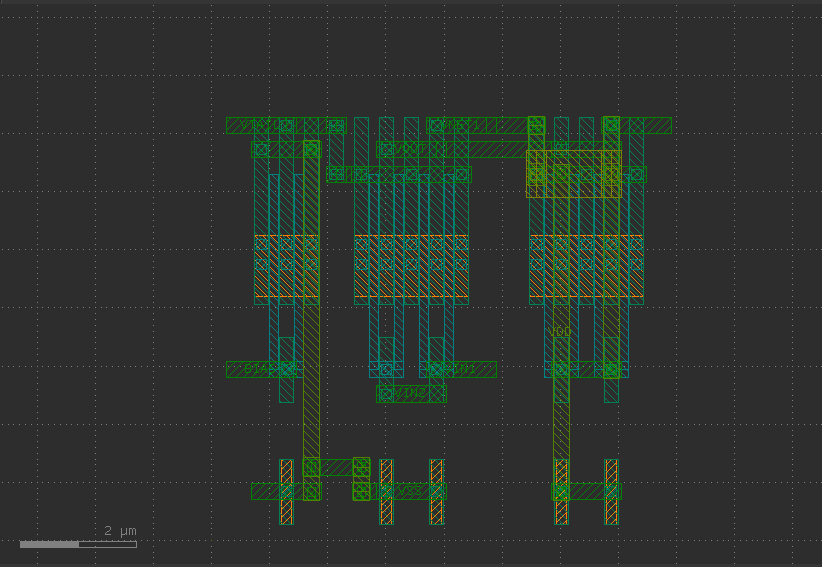

Additional layers and DRC/LVS checks can be done externally on Klayout